# Практична робота 4.3
## Використання методів штучного інтелекту для аналізу даних (регресія)

**Мета роботи:**
- опанувати базові методи регресії для аналізу даних;
- навчитися будувати модель регресії та оцінювати її ефективність засобами Python;
- застосувати реальний набір даних з Kaggle.

### 1. Завантаження даних

Використано той самий набір даних з Kaggle, що й у практичній роботі 3.5 —
пости соціальної мережі Reddit на тему війни в Україні.

Файл: `data/original_data.csv` — 10 000 записів, 12 стовпців.

**Задача регресії:** за характеристиками поста спрогнозувати його популярність —
кількість апвотів (`ups`).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('data/original_data.csv')

print('Розмір набору:', df.shape)
print(df.head())

Розмір набору: (10000, 12)
   Unnamed: 0           subreddit  \
0           0  NonCredibleDefense   
1           1             ukraine   
2           2   UkrainianConflict   
3           3              europe   
4           4              europe   

                                            selftext author_fullname  \
0                                                NaN     t2_4dfoopu9   
1                                                NaN     t2_3so708z2   
2                                                NaN     t2_p5qo3hyf   
3  \r\nThis megathread is meant for discussion of...        t2_ojkhp   
4  This megathread is meant for discussion of the...        t2_ojkhp   

                                               title  upvote_ratio    ups  \
0  Damn...we blinked and missed the T-34 stage of...          0.79  10398   
1  Finnish🇫🇮 volunteer sends greetings home from ...          0.90   2100   
2  Massive #HIMARS strikes 60km from the front in...          0.79    834   
3        

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10000 non-null  int64  
 1   subreddit        10000 non-null  str    
 2   selftext         4137 non-null   str    
 3   author_fullname  10000 non-null  str    
 4   title            10000 non-null  str    
 5   upvote_ratio     10000 non-null  float64
 6   ups              10000 non-null  int64  
 7   created          10000 non-null  int64  
 8   created_utc      10000 non-null  int64  
 9   num_comments     10000 non-null  int64  
 10  author           10000 non-null  str    
 11  id               10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB
None


### 2. Попередня обробка даних

#### 2.1. Пропущені значення та дублікати

In [3]:
# Перевірка на пропущені значення
print(df.isnull().sum())

Unnamed: 0            0
subreddit             0
selftext           5863
author_fullname       0
title                 0
upvote_ratio          0
ups                   0
created               0
created_utc           0
num_comments          0
author                0
id                    0
dtype: int64


In [4]:
# Службовий стовпець з номером рядка не потрібен
df = df.drop(columns=['Unnamed: 0'])

# Кожен пост у наборі повторюється стільки разів, скільки має коментарів.
# Для регресії дублікати неприпустимі: один і той самий пост потрапив би
# і в тренувальний, і в тестовий набір, і модель просто запам'ятала б відповідь.
print('Рядків у файлі:      ', len(df))
print('Унікальних постів:   ', df['id'].nunique())

df = df.drop_duplicates(subset='id').reset_index(drop=True)
print('Після дедублікації:  ', len(df))

Рядків у файлі:       10000
Унікальних постів:    241
Після дедублікації:   241


In [5]:
# Заповнення пропущених значень
# selftext порожній там, де пост є посиланням або картинкою.
# Замість видалення рядків створюємо ознаку "чи має пост текст".
df['has_text'] = df['selftext'].notna().astype(int)
df['selftext'] = df['selftext'].fillna('немає тексту')
df['author'] = df['author'].fillna('невідомий')
df['author_fullname'] = df['author_fullname'].fillna('невідомий')

print('Пропущених значень залишилось:', df.isnull().sum().sum())

Пропущених значень залишилось: 0


#### 2.2. Створення ознак для моделі

З часу публікації та заголовка отримуємо додаткові числові ознаки,
а назву спільноти перетворюємо на числовий код.

In [6]:
# Час публікації -> година та день тижня
created = pd.to_datetime(df['created_utc'], unit='s')
df['hour'] = created.dt.hour
df['weekday'] = created.dt.dayofweek

# Довжина заголовка
df['title_len'] = df['title'].str.len()

# Категоріальна змінна -> числова
df['subreddit_code'] = df['subreddit'].astype('category').cat.codes

print(df[['ups', 'num_comments', 'upvote_ratio', 'hour', 'title_len', 'subreddit_code']].head())

     ups  num_comments  upvote_ratio  hour  title_len  subreddit_code
0  10398           738          0.79    19         55               7
1   2100            57          0.90     4         58              41
2    834            41          0.79     4        259              18
3    578          8232          0.75    20         30              28
4    424          9524          0.76    22         27              28


#### 2.3. Аналіз кореляцій між числовими змінними

In [7]:
features = ['num_comments', 'upvote_ratio', 'hour', 'weekday',
            'title_len', 'has_text', 'subreddit_code']

correlation_matrix = df[features + ['ups']].corr()
print(correlation_matrix['ups'].round(3))

num_comments      0.113
upvote_ratio      0.020
hour              0.059
weekday           0.003
title_len        -0.045
has_text         -0.043
subreddit_code   -0.111
ups               1.000
Name: ups, dtype: float64


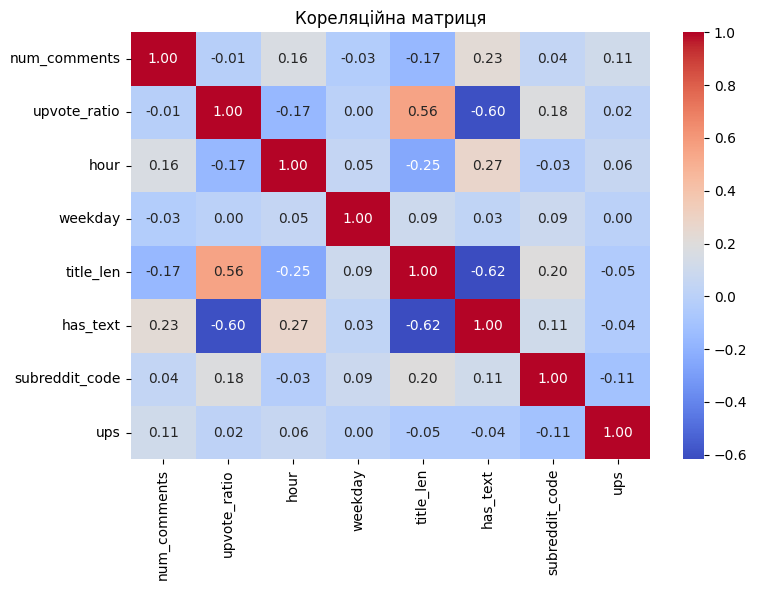

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

#### 2.4. Логарифмування цільової змінної

Подивимось на розподіл кількості апвотів.

count      241.0
mean        79.7
std        686.8
min          0.0
25%          1.0
50%          4.0
75%          9.0
max      10398.0
Name: ups, dtype: float64


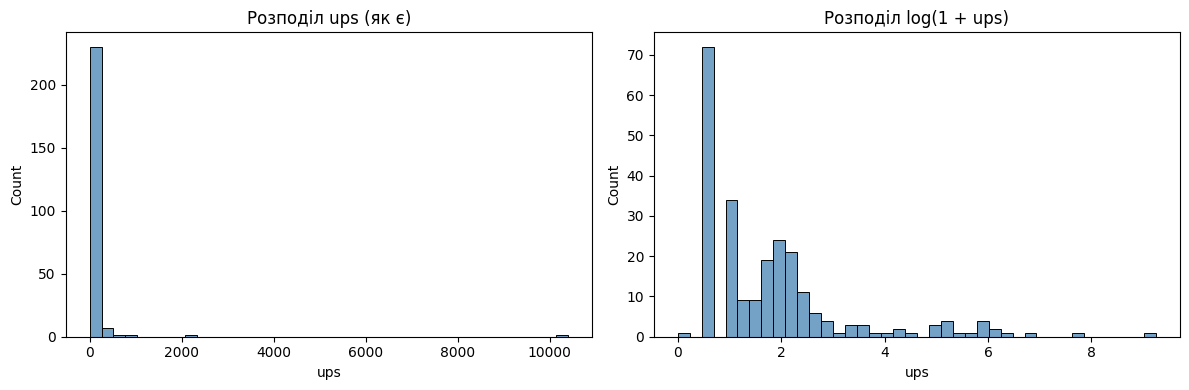

In [9]:
print(df['ups'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ups'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Розподіл ups (як є)')

sns.histplot(np.log1p(df['ups']), bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Розподіл log(1 + ups)')
plt.tight_layout()
plt.show()

In [10]:
# Розподіл сильно асиметричний: медіана 8 апвотів, максимум понад 10 000.
# Регресія на таких даних дає від'ємний R2 - кілька викидів псують усю модель.
# Тому цільову змінну логарифмуємо.
df['ups_log'] = np.log1p(df['ups'])

print('Асиметрія до логарифмування: ', round(df['ups'].skew(), 2))
print('Асиметрія після:             ', round(df['ups_log'].skew(), 2))

Асиметрія до логарифмування:  14.36
Асиметрія після:              1.96


### 3. Розподіл даних на тренувальний і тестовий набори (80 : 20)

In [11]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['ups_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Тренувальний набір:', X_train.shape)
print('Тестовий набір:    ', X_test.shape)

Тренувальний набір: (192, 7)
Тестовий набір:     (49, 7)


### 4. Побудова моделі лінійної регресії

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Коефіцієнти моделі
coef = pd.Series(model.coef_, index=features).round(4)
print(coef)
print()
print('Вільний член:', round(model.intercept_, 4))

num_comments      0.0006
upvote_ratio     -1.7310
hour              0.0008
weekday           0.0285
title_len        -0.0008
has_text          0.0700
subreddit_code   -0.0223
dtype: float64

Вільний член: 3.5443


In [13]:
# Прогноз на тестовому наборі
predictions = model.predict(X_test)
print(predictions[:10].round(2))

[1.89 2.32 1.84 1.23 1.38 1.9  1.26 1.81 5.28 2.32]


### 5. Оцінка моделі

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print('R2  =', round(r2, 3))
print('MSE =', round(mse, 3))

R2  = 0.345
MSE = 1.581


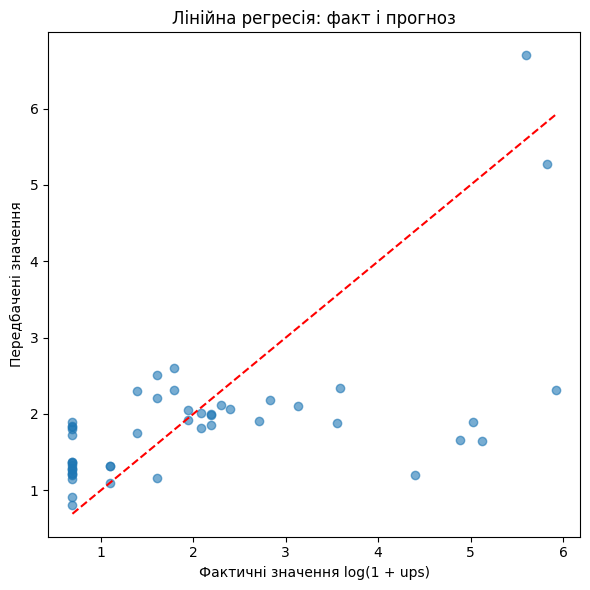

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактичні значення log(1 + ups)')
plt.ylabel('Передбачені значення')
plt.title('Лінійна регресія: факт і прогноз')
plt.tight_layout()
plt.show()

### 6. Додаткове завдання: порівняння алгоритмів регресії

Порівняємо лінійну регресію з Ridge, Lasso та деревом рішень
за коефіцієнтом детермінації R² і середньоквадратичною помилкою MSE.

In [16]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

models = {
    'Лінійна регресія': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Дерево рішень': DecisionTreeRegressor(max_depth=4, random_state=42),
}

results = []
all_predictions = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    all_predictions[name] = p
    results.append({
        'Модель': name,
        'R2': round(r2_score(y_test, p), 3),
        'MSE': round(mean_squared_error(y_test, p), 3),
    })

results_df = pd.DataFrame(results).set_index('Модель')
print(results_df)

                     R2    MSE
Модель                        
Лінійна регресія  0.345  1.581
Ridge             0.338  1.598
Lasso             0.311  1.663
Дерево рішень     0.687  0.755


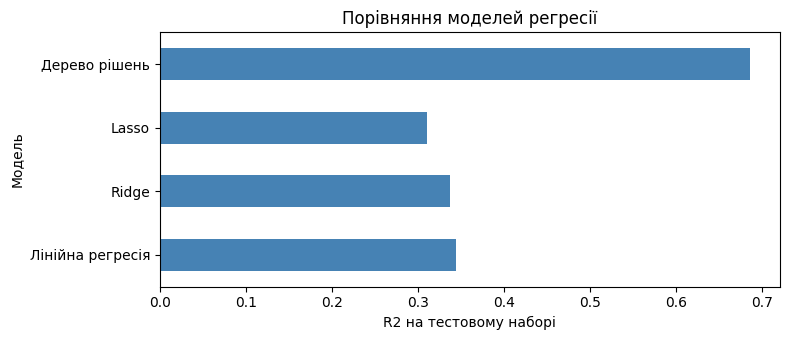

In [17]:
results_df['R2'].plot(kind='barh', color='steelblue', figsize=(8, 3.5))
plt.xlabel('R2 на тестовому наборі')
plt.title('Порівняння моделей регресії')
plt.tight_layout()
plt.show()

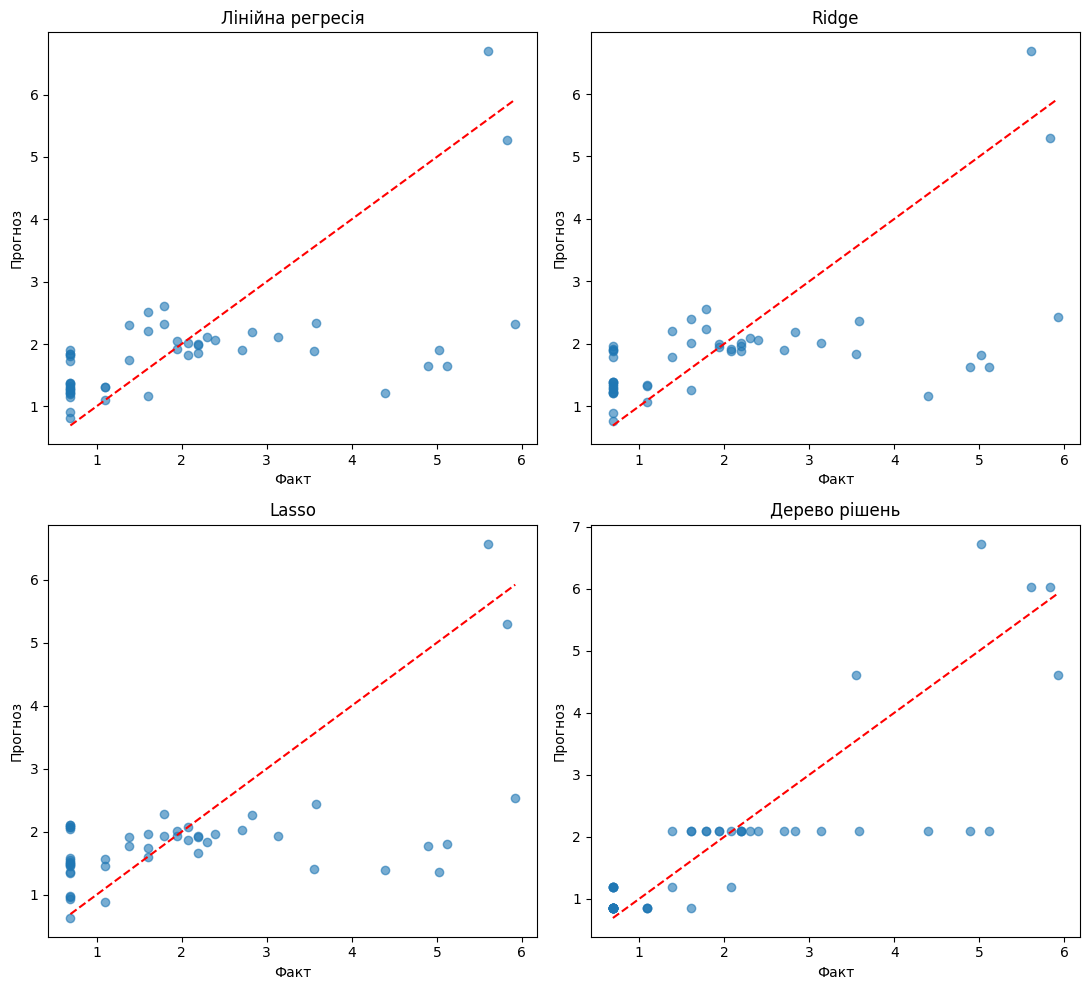

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, (name, p) in zip(axes.ravel(), all_predictions.items()):
    ax.scatter(y_test, p, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Факт')
    ax.set_ylabel('Прогноз')

plt.tight_layout()
plt.show()

In [19]:
# Які ознаки дерево рішень вважає найважливішими
tree = models['Дерево рішень']
importance = pd.Series(tree.feature_importances_, index=features).sort_values(ascending=False)
print(importance.round(3))

num_comments      0.532
upvote_ratio      0.341
title_len         0.118
hour              0.005
subreddit_code    0.004
weekday           0.000
has_text          0.000
dtype: float64


### 7. Звіт

**Використаний підхід.**
Набір даних з Kaggle — 10 000 записів про пости Reddit на тему війни в Україні.
Задача: за характеристиками поста спрогнозувати кількість апвотів.

Обробка виконана в такому порядку:

1. Видалено службовий стовпець `Unnamed: 0`.
2. Проведено дедублікацію за `id`. Виявилось, що 10 000 рядків описують
   лише 241 унікальний пост — кожен пост повторюється стільки разів,
   скільки має зібраних коментарів. Без цього кроку один і той самий пост
   потрапляє і в тренувальний, і в тестовий набір; дерево рішень тоді показує
   R² = 1.00, але це фіктивний результат — модель просто запам'ятала відповіді.
3. Пропуски були лише у текстових стовпцях. Замість видалення рядків створено
   бінарну ознаку `has_text`.
4. Сформовано сім ознак: кількість коментарів, частка позитивних голосів,
   година та день тижня публікації, довжина заголовка, наявність тексту,
   код спільноти.
5. Цільову змінну логарифмовано.

**Чому знадобилось логарифмування.**
Розподіл `ups` украй асиметричний: медіана — 8 апвотів, максимум — понад 10 000.
На вихідних значеннях усі лінійні моделі дають **від'ємний R²**, тобто працюють
гірше за просте передбачення середнього: кілька вірусних постів перетягують
на себе всю регресію. Після переходу до `log(1 + ups)` асиметрія зникає,
і моделі починають працювати.

**Ключові результати.**

| Модель | R² | MSE |
|---|---|---|
| Лінійна регресія | 0.345 | 1.581 |
| Ridge | 0.338 | 1.598 |
| Lasso | 0.311 | 1.663 |
| **Дерево рішень** (max_depth=4) | **0.687** | **0.755** |

Ridge і Lasso практично повторюють лінійну регресію — це очікувано,
бо ознак лише сім і серед них немає сильно корельованих між собою,
тож регуляризації нема чого стримувати. Lasso трохи гірший, бо занулює
частину коефіцієнтів.

Дерево рішень удвічі кращий за R² і вдвічі менша помилка. Причина в тому,
що залежність нелінійна: кореляція `ups` з кількістю коментарів — лише 0.11,
але зв'язок існує, просто він не прямий. Дерево вловлює його через пороги
(«якщо коментарів більше N — апвотів багато»), чого лінійна модель не вміє.

**Висновки.**

1. Найважливіша ознака для прогнозу популярності — кількість коментарів.
   Обговорюваність і популярність поста зростають разом.
2. Якість даних важливіша за вибір алгоритму. Дедублікація і логарифмування
   змінили результат більше, ніж перехід між моделями: без них найкраща
   модель показувала або фіктивну одиницю, або від'ємний R².
3. Для асиметричних даних із викидами дерево рішень працює краще
   за лінійні моделі.
4. R² = 0.69 означає, що модель пояснює приблизно дві третини розкиду
   популярності. Обмеження роботи: після дедублікації залишилось 241 запис,
   тестовий набір — 49 постів, тож оцінка має широкий довірчий інтервал.
   Крім того, `num_comments` стає відомим лише після публікації, тому модель
   пояснює популярність, а не прогнозує її наперед.